## YaRN scaling

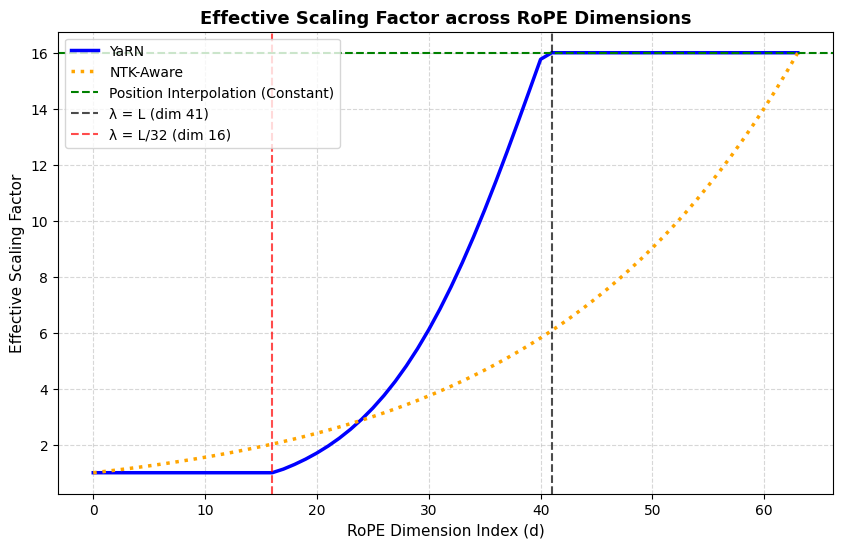

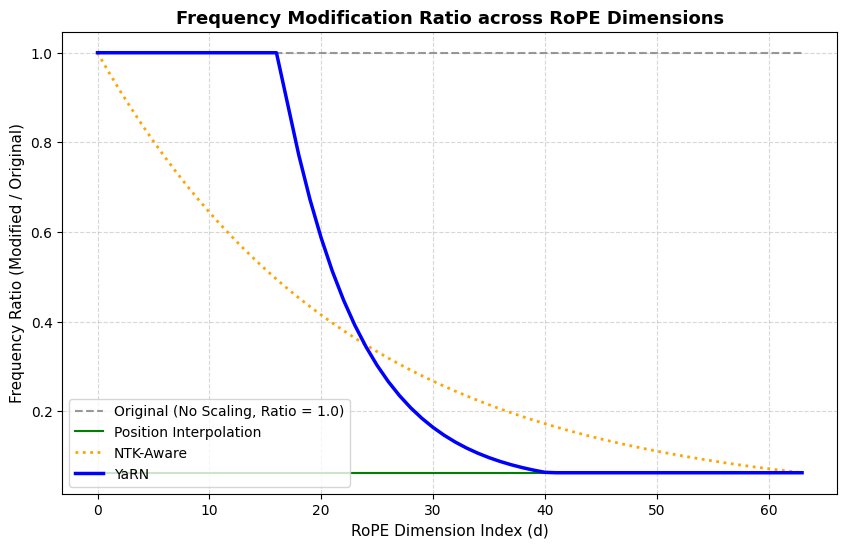

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
D = 128               # Full RoPE dimension
base = 10000          # Base frequency
L = 2048              # Original pre-trained context length
scale = 16            # Context extension scale factor (L' = scale * L)

alpha = 1             # YaRN lower threshold
beta = 32             # YaRN upper threshold

# ----------------------------
# Original Frequencies & Wavelengths
# ----------------------------
# RoPE uses pairs of dimensions; D // 2 unique frequencies
d = np.arange(D // 2)

theta = base ** (-2 * d / D)
lam = 2 * np.pi / theta
r = L / lam

# ----------------------------
# 1. Position Interpolation (PI)
# ----------------------------
theta_pi = theta / scale
effective_scale_pi = np.full_like(theta, scale)

# ----------------------------
# 2. NTK-Aware Scaling
# ----------------------------
base_ntk = base * (scale ** (D / (D - 2)))
theta_ntk = base_ntk ** (-2 * d / D)
effective_scale_ntk = theta / theta_ntk

# ----------------------------
# 3. YaRN (Yet Another RoPE extensioN)
# ----------------------------
gamma = np.zeros_like(r)

gamma[r <= alpha] = 0
gamma[r >= beta] = 1

mask = (r > alpha) & (r < beta)
gamma[mask] = (r[mask] - alpha) / (beta - alpha)

# Compute YaRN effective scaling factor and frequencies
effective_scale_yarn = scale / (1 + gamma * (scale - 1))
theta_yarn = theta / effective_scale_yarn

# Find the dimension indices where thresholds occur for visual markers
# alpha threshold: r <= alpha -> lam >= L -> where wavelength exceeds L
d_alpha = d[r <= alpha][0] if np.any(r <= alpha) else None
# beta threshold: r >= beta -> lam <= L/32 -> where wavelength is very small
d_beta = d[r >= beta][-1] if np.any(r >= beta) else None

# ----------------------------
# Plot 1: Effective Scaling Factor vs. Dimension Index
# ----------------------------
plt.figure(figsize=(10, 6))

plt.plot(d, effective_scale_yarn, linewidth=2.5, color='blue', label='YaRN')
plt.plot(d, effective_scale_ntk, linestyle=':', linewidth=2.5, color='orange', label='NTK-Aware')
plt.axhline(scale, color='green', linestyle='--', label='Position Interpolation (Constant)')

# Visual thresholds mapped to dimensions
if d_alpha is not None:
    plt.axvline(d_alpha, color='k', linestyle='--', alpha=0.7, label=f'λ = L (dim {d_alpha})')
if d_beta is not None:
    plt.axvline(d_beta, color='r', linestyle='--', alpha=0.7, label=f'λ = L/{beta} (dim {d_beta})')

plt.xlabel("RoPE Dimension Index (d)", fontsize=11)
plt.ylabel("Effective Scaling Factor", fontsize=11)
plt.title("Effective Scaling Factor across RoPE Dimensions", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.show()

# ----------------------------
# Plot 2: Frequency Ratio (Modified / Original) vs. Dimension Index
# ----------------------------
# Plotting the ratio h(theta)/theta directly shows how much each dimension is modified
plt.figure(figsize=(10, 6))

plt.plot(d, theta / theta, '--', color='gray', alpha=0.8, label='Original (No Scaling, Ratio = 1.0)')
plt.plot(d, theta_pi / theta, label='Position Interpolation', color='green')
plt.plot(d, theta_ntk / theta, label='NTK-Aware', linestyle=':', color='orange', linewidth=2)
plt.plot(d, theta_yarn / theta, linewidth=2.5, color='blue', label='YaRN')

plt.xlabel("RoPE Dimension Index (d)", fontsize=11)
plt.ylabel("Frequency Ratio (Modified / Original)", fontsize=11)
plt.title("Frequency Modification Ratio across RoPE Dimensions", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left')

plt.show()